In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from scipy.spatial.distance import cdist

# Dataset Merging

In [2]:
train_csv = pd.read_csv('fashion-mnist_train.csv')
test_csv = pd.read_csv('fashion-mnist_test.csv')
df = pd.concat([train_csv, test_csv], ignore_index=True)

In [3]:
print(f"Original train set shape: {train_csv.shape} and original test set shape: {test_csv.shape}")
print(f"Merged dataset shape: {df.shape}")

Original train set shape: (60000, 785) and original test set shape: (10000, 785)
Merged dataset shape: (70000, 785)


In [4]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape

(70000, 785)

In [6]:
labels = df['label'].values
features = df.drop(columns=['label']).values

# Sampling Methods

In [98]:
def sequential_sampling(n,n_classes):
  train_indices=[]
  test_indices=[]
  for c in range(n_classes):
    class_indices = np.where(labels==c)[0]
    class_train_indices = class_indices[:n]
    class_test_indices = class_indices[n:]
    train_indices.extend(class_train_indices)
    test_indices.extend(class_test_indices)
  return np.array(train_indices), np.array(test_indices)

def random_sampling(labels, n, n_classes):
  train_indices = []
  for c in range(n_classes):
    class_indices = np.where(labels==c)[0]
    class_sample = np.random.choice(class_indices, n, replace=False)
    train_indices.extend(class_sample)
  train_indices = np.array(train_indices)
  test_indices = np.setdiff1d(np.arange(len(labels)), train_indices)
  return train_indices, test_indices


In [99]:
def euclidean_distance_matrix(test_data, train_data):
  dist_matrix = cdist(test_data, train_data, metric='euclidean')
  return dist_matrix

def l1_norm_distance_matrix(test_data, train_data):
  dist_matrix = cdist(test_data, train_data, metric="cityblock")
  return dist_matrix

# KNN

In [96]:
def knn(features, n_values, labels, k_values, n_classes, sampling, batch_size=1000):
  result = []
  max_n = max(n_values)
  max_k = max(k_values)
  if sampling == "random":
    np.random.seed(42)
  for n in sorted(n_values, reverse=True):
    if sampling == "sequential":
      train_indices_n, test_indices_n = sequential_sampling(n,n_classes)
    elif sampling == "random":
      train_indices_n, test_indices_n = random_sampling(labels, n, n_classes)
    train_features_n = features[train_indices_n]
    test_features_n = features[test_indices_n]
    train_labels_n = labels[train_indices_n]
    test_labels_n = labels[test_indices_n]
    sorted_indices_n = np.zeros((len(test_indices_n), max_k), dtype=np.int32)

    for i in range(0, len(test_indices_n), batch_size):
      batch = features[test_indices_n[i:i+batch_size]]
      batch_dist = euclidean_distance_matrix(batch, train_features_n)
      sorted_indices_n[i:i+batch_size] = np.argsort(batch_dist, axis=1)[:,:max_k]

    for k in k_values:
      neighbor_indices = sorted_indices_n[:,:k]
      neighbor_labels = train_labels_n[neighbor_indices]
      predicted_label = stats.mode(neighbor_labels, axis=1, keepdims=True).mode.flatten()
      global_accuracy = np.mean(predicted_label == test_labels_n)

      local_acc = {}
      for c in range(n_classes):
        test_label_c = (test_labels_n == c)
        local_acc[c] = np.mean(predicted_label[test_label_c] == test_labels_n[test_label_c])


      result.append({
          'N':n,
          'k':k,
          'global_accuracy':global_accuracy,
          'local_accuracy': local_acc})
  return result


In [43]:
def knn_l1(features, n_values, labels, k_values, n_classes, sampling, batch_size=1000):
  result = []
  max_n = max(n_values)
  max_k = max(k_values)
  if sampling == "random":
    np.random.seed(42)
  for n in sorted(n_values, reverse=True):
    if sampling == "sequential":
      train_indices_n, test_indices_n = sequential_sampling(n)
    elif sampling == "random":
      train_indices_n, test_indices_n = random_sampling(labels, n, n_classes)
    train_features_n = features[train_indices_n]
    test_features_n = features[test_indices_n]
    train_labels_n = labels[train_indices_n]
    test_labels_n = labels[test_indices_n]
    sorted_indices_n = np.zeros((len(test_indices_n), max_k), dtype=np.int32)

    for i in range(0, len(test_indices_n), batch_size):
      batch = features[test_indices_n[i:i+batch_size]]
      batch_dist = l1_norm_distance_matrix(batch, train_features_n)
      sorted_indices_n[i:i+batch_size] = np.argsort(batch_dist, axis=1)[:,:max_k]

    for k in k_values:
      neighbor_indices = sorted_indices_n[:,:k]
      neighbor_labels = train_labels_n[neighbor_indices]
      predicted_label = stats.mode(neighbor_labels, axis=1, keepdims=True).mode.flatten()
      global_accuracy = np.mean(predicted_label == test_labels_n)

      local_acc = {}
      for c in range(n_classes):
        test_label_c = (test_labels_n == c)
        local_acc[c] = np.mean(predicted_label[test_label_c] == test_labels_n[test_label_c])


      result.append({
          'N':n,
          'k':k,
          'global_accuracy':global_accuracy,
          'local_accuracy': local_acc})
  return result

# Question 1

In [7]:
n_values = [1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000]
k = [1, 2, 5, 10, 15, 20]
limit = 7000
n_classes = 10
max_n = max(n_values)
max_n

6000

In [ ]:
knn_result1 = knn(features, n_values,labels,k,n_classes,"sequential")

# Question 2

In [24]:
knn_result2 = knn(features, n_values,labels,k,n_classes,"random")

# Question 3

In [44]:
knn_result3 = knn_l1(features, n_values,labels,k,n_classes,"sequential")

## Global Accuracy Result

In [25]:
def get_dataframe(result):
  result_df = pd.DataFrame([
    {'N': d['N'], 'k': d['k'], 'global_accuracy': d['global_accuracy']}
    for d in result
  ])
  result_df = result_df.pivot(index='N', columns='k', values='global_accuracy')
  result_df.columns = [f'k={k}' for k in result_df.columns]
  result_df.index.name = 'N'
  result_df = result_df.round(2)
  return result_df

In [97]:
def plot_global_accuracy(data, title, xlabel, ylabel, ax=None):
  if ax is None:
        fig, ax = plt.subplots(figsize=(15, 5))
    
  sns.lineplot(data=data, ax=ax, markers=True)
  ax.set_title(title)
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)

In [106]:
def plot_difference_heatmap(diff_df, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 5))
    
    sns.heatmap(diff_df, cmap='coolwarm', annot=True, linewidths=.5, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('k')
    ax.set_ylabel('N')

In [35]:
#Global accuracies for approach 1
result_df1 = get_dataframe(knn_result1)
result_df1

,k=1,k=2,k=5,k=10,k=15,k=20
N,,,,,,
1000,0.82,0.81,0.82,0.82,0.82,0.81
1500,0.82,0.82,0.83,0.83,0.82,0.82
2000,0.83,0.83,0.84,0.83,0.83,0.83
2500,0.84,0.83,0.84,0.84,0.83,0.83
3000,0.84,0.84,0.84,0.84,0.84,0.83
3500,0.84,0.84,0.85,0.84,0.84,0.84
4000,0.84,0.84,0.85,0.85,0.84,0.84
4500,0.85,0.84,0.85,0.85,0.85,0.84
5000,0.85,0.85,0.85,0.85,0.85,0.84


In [29]:
#Global accuracies for approach 2
result_df2 = get_dataframe(knn_result2)
result_df2

,k=1,k=2,k=5,k=10,k=15,k=20
N,,,,,,
1000,0.81,0.82,0.83,0.82,0.82,0.81
1500,0.82,0.82,0.83,0.83,0.82,0.82
2000,0.83,0.83,0.84,0.84,0.83,0.83
2500,0.84,0.84,0.84,0.84,0.84,0.83
3000,0.84,0.84,0.85,0.84,0.84,0.83
3500,0.84,0.84,0.85,0.85,0.84,0.84
4000,0.85,0.85,0.85,0.85,0.85,0.84
4500,0.85,0.85,0.86,0.85,0.85,0.84
5000,0.86,0.85,0.86,0.86,0.85,0.85


In [126]:
#Difference between the global accuracies of first two results
global_diff_21 = (result_df2 - result_df1).abs()
global_diff_21

,k=1,k=2,k=5,k=10,k=15,k=20
N,,,,,,
1000,0.01,0.01,0.01,0.00,0.00,0.00
1500,0.00,0.00,0.00,0.00,0.00,0.00
2000,0.00,0.00,0.00,0.01,0.00,0.00
2500,0.00,0.01,0.00,0.00,0.01,0.00
3000,0.00,0.00,0.01,0.00,0.00,0.00
3500,0.00,0.00,0.00,0.01,0.00,0.00
4000,0.01,0.01,0.00,0.00,0.01,0.00
4500,0.00,0.01,0.01,0.00,0.00,0.00
5000,0.01,0.00,0.01,0.01,0.00,0.01


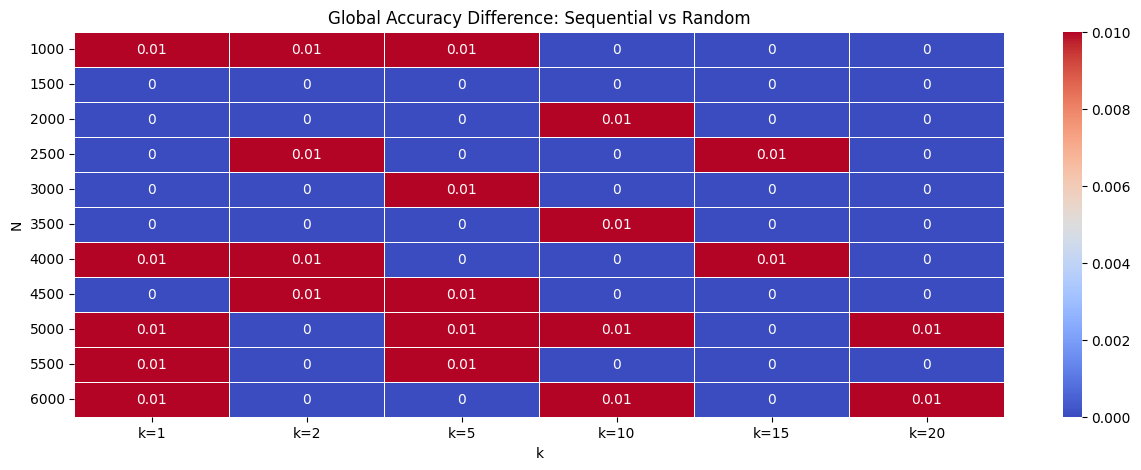

In [130]:
plot_difference_heatmap(global_diff_21, 'Global Accuracy Difference: Sequential vs Random')

In [45]:
#Global accuracies when L1 Norm used 
result_df3 = get_dataframe(knn_result3)
result_df3

,k=1,k=2,k=5,k=10,k=15,k=20
N,,,,,,
1000,0.82,0.82,0.83,0.83,0.82,0.82
1500,0.83,0.83,0.84,0.83,0.83,0.83
2000,0.84,0.83,0.85,0.84,0.84,0.83
2500,0.84,0.84,0.85,0.85,0.84,0.84
3000,0.84,0.84,0.85,0.85,0.84,0.84
3500,0.84,0.84,0.85,0.85,0.85,0.84
4000,0.85,0.85,0.86,0.85,0.85,0.85
4500,0.85,0.85,0.86,0.86,0.85,0.85
5000,0.85,0.85,0.86,0.86,0.85,0.85


In [109]:
global_diff_32 = (result_df3 - result_df2).abs()
global_diff_32

,k=1,k=2,k=5,k=10,k=15,k=20
N,,,,,,
1000,0.01,0.00,0.00,0.01,0.00,0.01
1500,0.01,0.01,0.01,0.00,0.01,0.01
2000,0.01,0.00,0.01,0.00,0.01,0.00
2500,0.00,0.00,0.01,0.01,0.00,0.01
3000,0.00,0.00,0.00,0.01,0.00,0.01
3500,0.00,0.00,0.00,0.00,0.01,0.00
4000,0.00,0.00,0.01,0.00,0.00,0.01
4500,0.00,0.00,0.00,0.01,0.00,0.01
5000,0.01,0.00,0.00,0.00,0.00,0.00


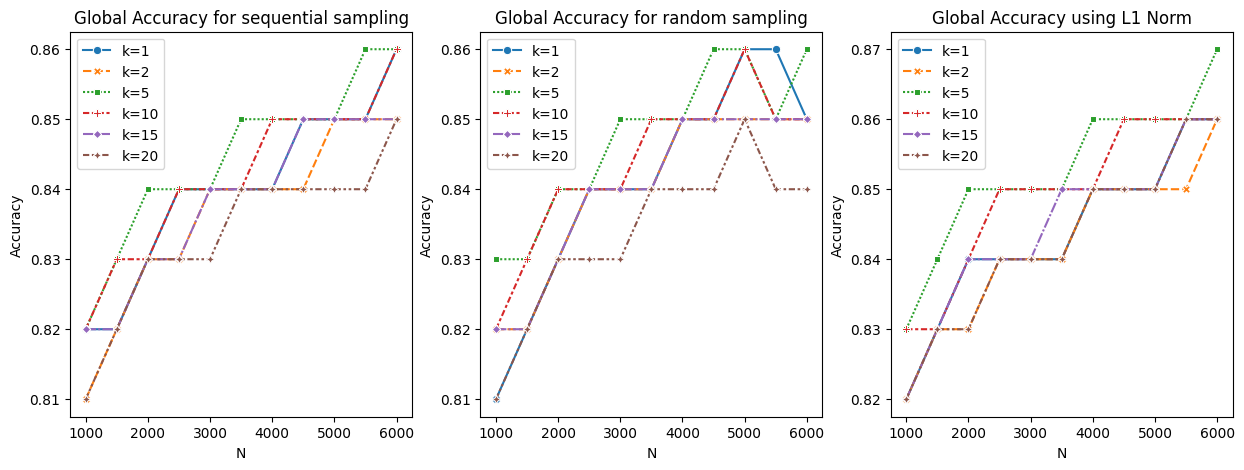

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

In [87]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,5))
plot_global_accuracy(result_df1, "Global Accuracy for sequential sampling", "N", "Accuracy", ax1)
plot_global_accuracy(result_df2, "Global Accuracy for random sampling", "N", "Accuracy", ax2)
plot_global_accuracy(result_df3, "Global Accuracy using L1 Norm", "N", "Accuracy",ax3)
plt.tight_layout()
plt.show()

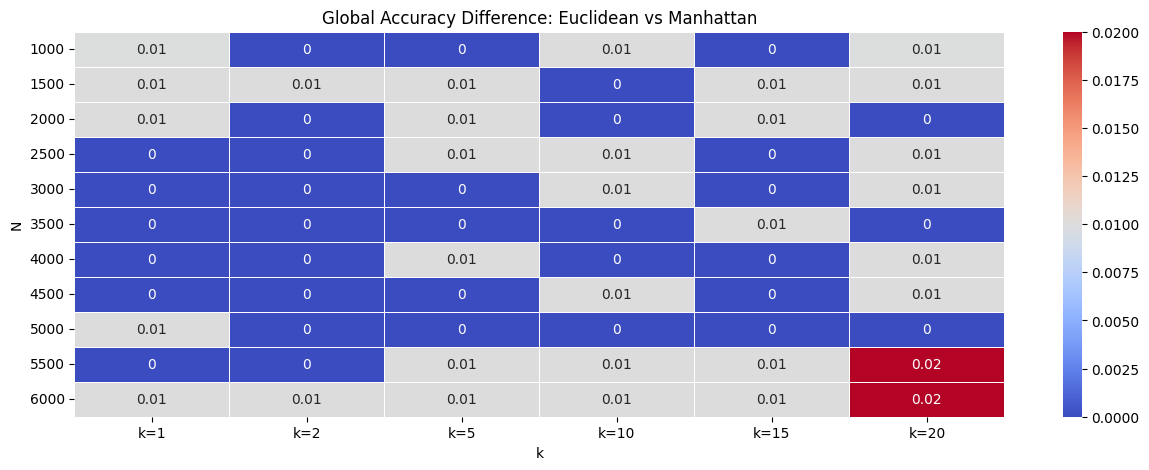

In [132]:
# Difference between the results of 3rd and 2nd result
plot_difference_heatmap(global_diff_32, 'Global Accuracy Difference: Euclidean vs Manhattan')

## Local Accuracy Result

In [31]:
def plot_local_accuracies(results):
  n_values = sorted(set(d['N'] for d in results))
  k_values = sorted(set(d['k'] for d in results))
  colors = cm.tab10(np.linspace(0, 1, 10))
  fig, axes = plt.subplots(2, 3, figsize=(15,8))
  axes = axes.flatten()

  for ax, k in zip(axes, k_values):
      k_results = sorted([d for d in results if d['k'] == k], key=lambda d: d['N'])
      n_values_k = [d['N'] for d in k_results]

      for c in range(10):
          accuracies = [d['local_accuracy'][c] for d in k_results]
          ax.plot(n_values_k, accuracies, marker='o', markersize=4,
                  color=colors[c], label=f'Class {c}')

      ax.set_title(f'k={k}')
      ax.set_xlabel('N')
      ax.set_ylabel('Local Accuracy')
      ax.set_xticks(n_values_k)
      ax.tick_params(axis='x', rotation=45)

  handles, labels = axes[0].get_legend_handles_labels()
  fig.legend(handles, labels, title='Class', bbox_to_anchor=(1.01, 0.5), loc='center left')
  plt.suptitle('Local Accuracy per Class for each k')
  plt.tight_layout()
  plt.show()

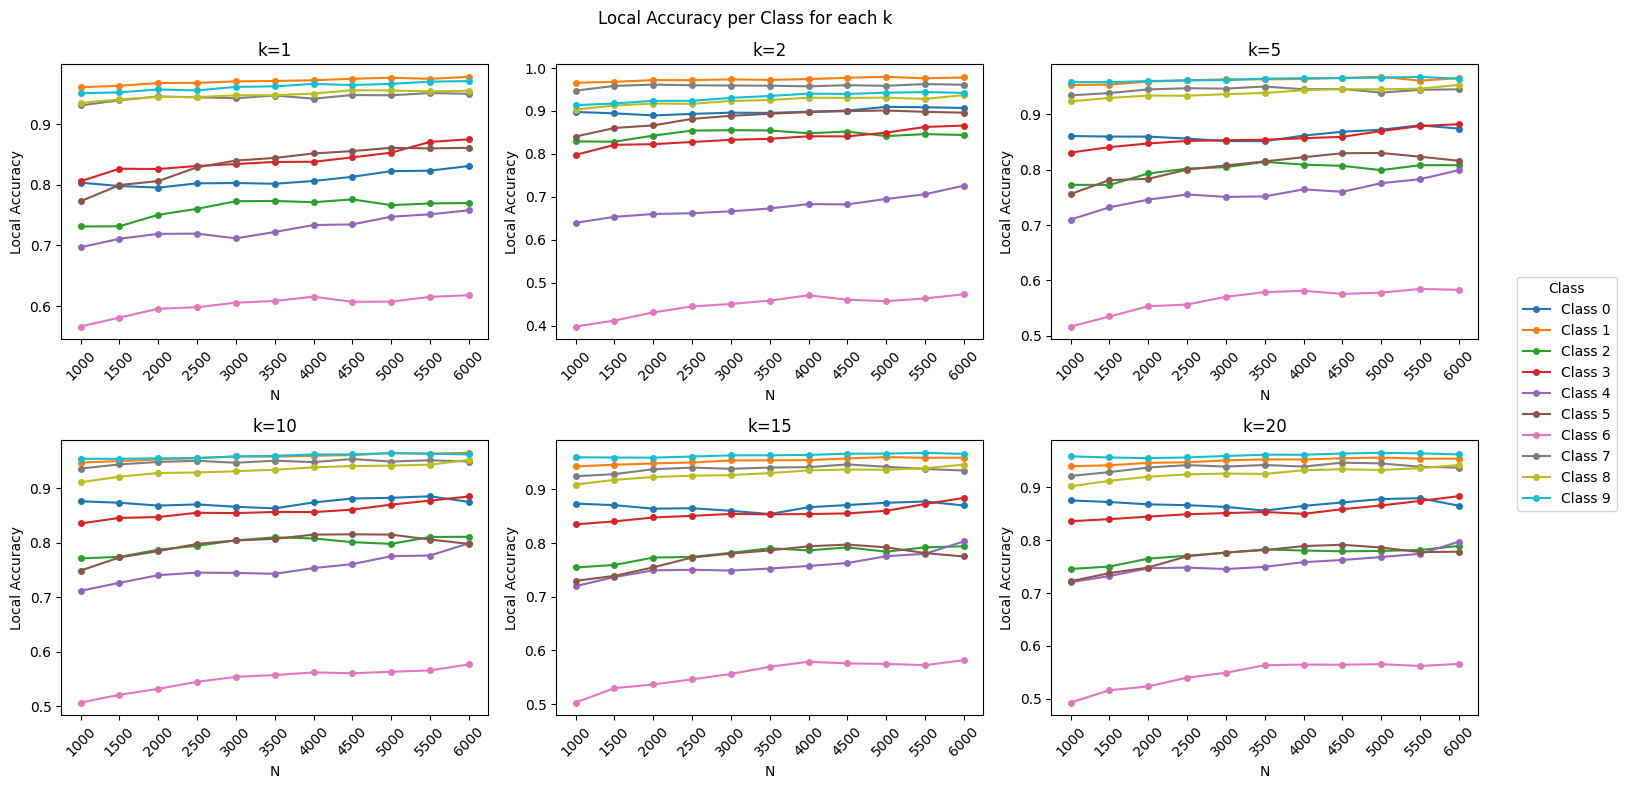

In [128]:
# Local accuracies in result 1
plot_local_accuracies(knn_result1)

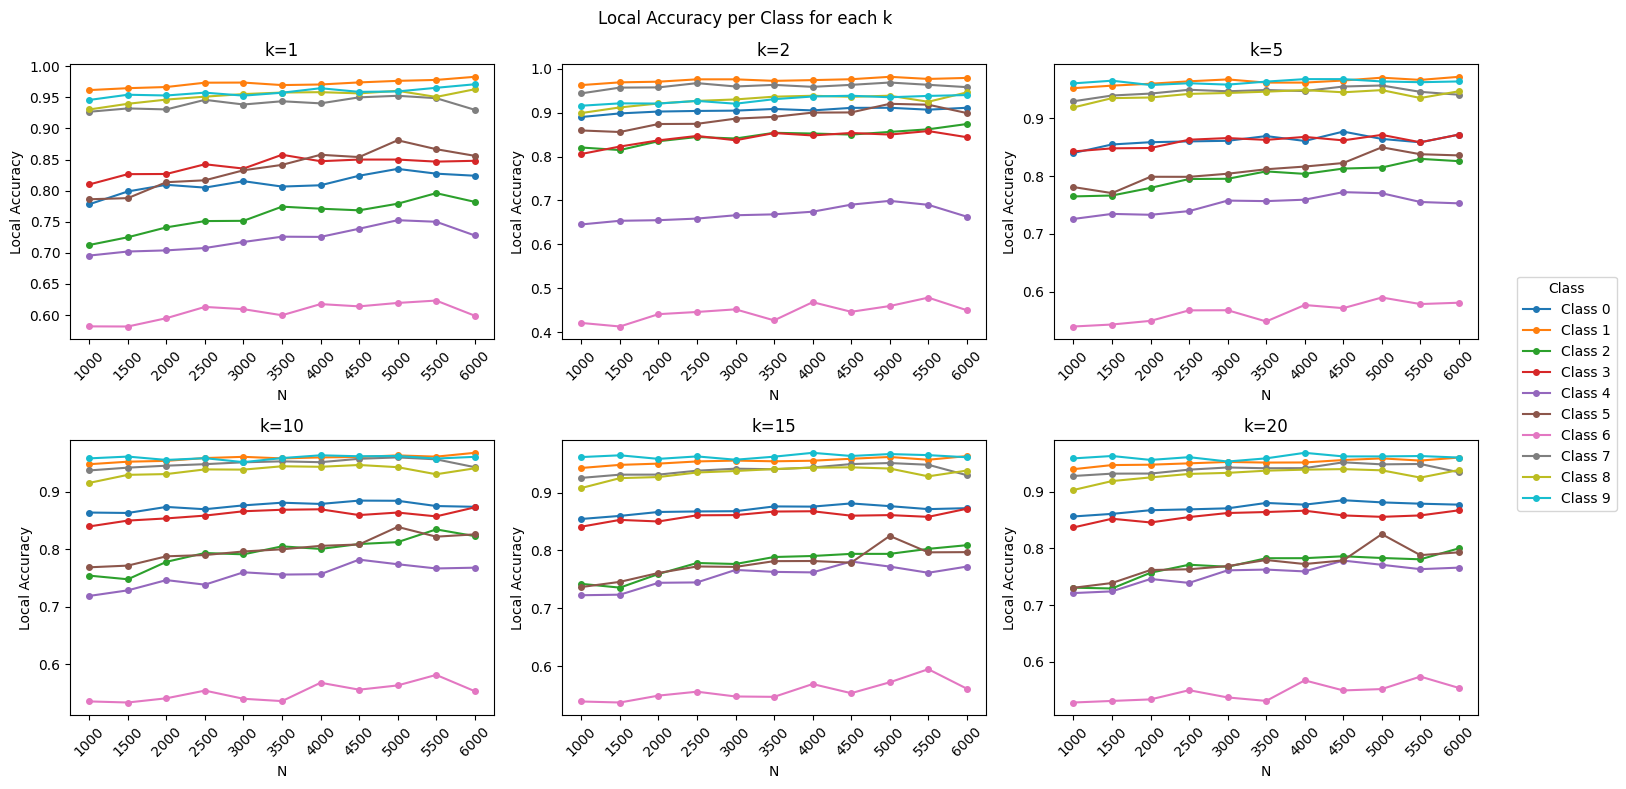

In [129]:
# Local accuracies in result 2
plot_local_accuracies(knn_result2)

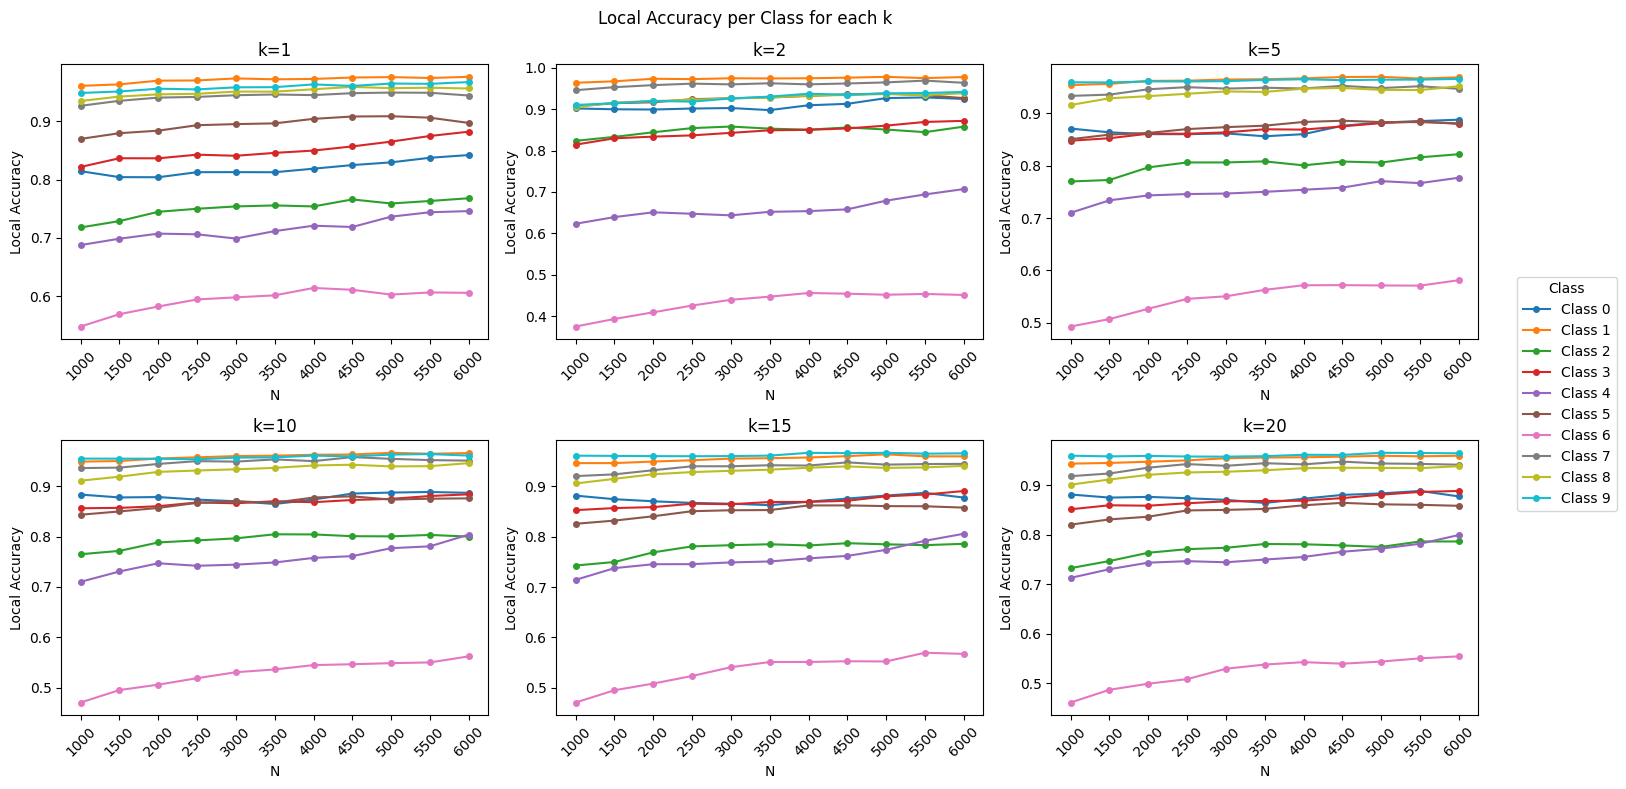

In [131]:
#Local accuracies in result 3: 
plot_local_accuracies(knn_result3)